# **FINAL PROJECT PT 2 .- GRID SEARCHES: Manual Printing Version (FOR LOOPS) vs Tensorboard Printing (H PARAMS)**

# FASHION MNIST DATASET: GRID SEARCH VS KERAS TUNNER | FINAL PROJECT

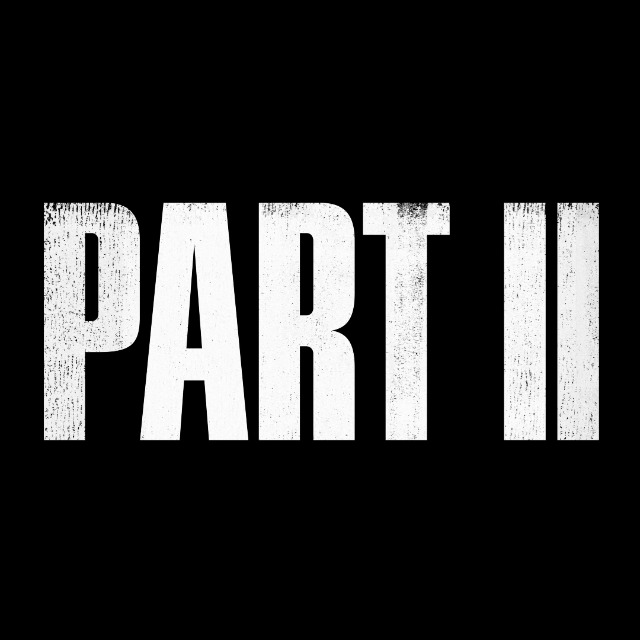

BOTH PART A AND B EXPLORE...
two convolutional architectures:

- Simple_3x3: Conv(3×3) → MaxPooling → Flatten → Dense → Dropout → Output

- Optimized_1x1: Conv(1×1) → Conv(3×3) → MaxPooling → Flatten → Dense → Dropout → Output

The second architecture introduces a 1×1 bottleneck layer before the 3×3 convolution to enable channel-wise feature recombination.

The architectures are identical in both parts A and B. What changes is how many hyperparameters we explore.

- A (manual): fewer hyperparameters → smaller search
- B (TensorBoard): more hyperparameters → full grid

Each experiment corresponds to a configuration defined by:

- f(architecture, neurons, optimizer, dropout, batch size)


Therefore, architecture is only one factor within a broader hyperparameter search, and performance differences cannot be attributed solely to architectural changes.

# Part 2 Outline:


It compares 2 different architectures 'Simple_3x3 Architecture (6 Layers)' vs 'Optimized_1x1 Architecture (7 Layers)'



2.-


A) MANUAL PRINTING EXPLORES:

- arch: Simple_3x3, Optimized_1x1
- neurons: 64, 128
- Opt: Adam, SGD, RMSprop
- Dropout: 0.3
- Batchsize: 64 only
- * --> Manual: 2 (Arch) × 2 (Neurons) × 3 (Opt) = 12 total runs.*


B) TENSORBOARD GRIDSEARCH:
* 2 (Arch) × 2 (Neurons) × 2 (Dropout) × 3 (Opt) × 2 (Batch) = 48 total runs.

- arch: Simple_3x3, Optimized_1x1
- neurons: 64, 128
- Opt: Adam, SGD, RMSprop
- Dropout: 0.3 vs 0.5
- Batchsize: 32 vs 64

- * --> 2 (Arch) × 2 (Neurons) × 2 (Dropout) × 3 (Opt) × 2 (Batch) = 48 total runs.*






---
---
---
---
---
---
---
---
---
---


Simple_3x3 Architecture (6 Layers)

When the architecture is not 'Optimized_1x1', it follows the else logic:

    Conv2D: The single 3×3 layer.

    MaxPooling2D: Downsampling.

    Flatten: Converts the 2D feature maps to a 1D vector.

    Dense: The first fully connected layer (with units defined by HP_NUM_UNITS).

    Dropout: The regularization layer.

    Dense: The final output layer (10 units for classification).


Optimized_1x1 Architecture (7 Layers)

When the architecture is 'Optimized_1x1', the code adds an extra convolutional step:

    Conv2D: The 1×1 "bottleneck" layer.

    Conv2D: The 3×3 layer.

    MaxPooling2D: Downsampling.

    Flatten: Converts to 1D vector.

    Dense: The first fully connected layer.

    Dropout: The regularization layer.

    Dense: The final output layer.

# PART 2.- GRID SEARCH

### A) GRID SEARCH MANUALLY

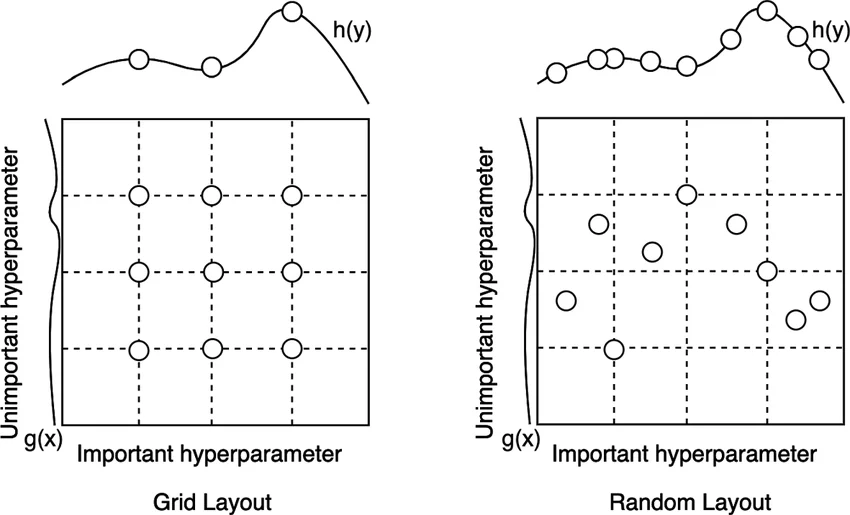

In [ ]:
# GRID SEARCH MANUALLY

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import time

# ============================================
# DATA PREPARATION FUNCTION (CNN VERSION) - SUBSET OR COMPLETE
# ============================================
def load_and_preprocess_fashion_mnist_cnn(use_subset=True):
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
    X_train_orig, X_test_orig = X_train.copy(), X_test.copy()

    if use_subset:
        n_train = int(X_train.shape[0] * 0.2)
        indices = np.random.choice(X_train.shape[0], n_train, replace=False)
        X_train, y_train = X_train[indices], y_train[indices]

    # Normalization & Reshape for CNN
    X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
    X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0
    return X_train, y_train, X_test, y_test, X_train_orig, X_test_orig



29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# ============================================
# DATA LOADING -- SUBSET OR COMPLETE
# ============================================

X_train, y_train, X_test, y_test, X_orig, X_test_orig = load_and_preprocess_fashion_mnist_cnn()
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [ ]:
def show_sample_predictions(model, X_test, y_test, class_names, num_samples=5):
    """Display sample predictions for a Keras model"""

    # 1. Get predictions from the Keras model
    # We use np.argmax because the model output is logits/softmax probabilities
    predictions_raw = model.predict(X_test)
    predictions = np.argmax(predictions_raw, axis=1)

    # 2. Setup the plot
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 4))

    for i in range(num_samples):
        # Pick a random index
        idx = np.random.randint(0, len(X_test))

        # Display image (reshape back to 28x28 for plotting)
        axes[i].imshow(X_test[idx].reshape(28, 28), cmap='gray')

        pred_label = class_names[predictions[idx]]
        actual_label = class_names[y_test[idx]]

        axes[i].set_title(f'Pred: {pred_label}\nActual: {actual_label}', fontsize=10)
        axes[i].axis('off')

        # Color code: green if correct, red if wrong
        if predictions[idx] == y_test[idx]:
            axes[i].title.set_color('green')
        else:
            axes[i].title.set_color('red')

    plt.tight_layout()
    plt.show()

    # 3. Print a quick text summary
    print("\n📊 Sample Summary:")
    for i in range(num_samples):
        idx = np.random.randint(0, len(X_test))
        is_correct = "✅" if predictions[idx] == y_test[idx] else "❌"
        print(f"{is_correct} Predicted: {class_names[predictions[idx]]:12s} | Actual: {class_names[y_test[idx]]}")

In [ ]:
# ============================================
# GLOBAL VISUALIZATION (COMPARE ALL MODELS)
# ============================================
def plot_all_results(all_histories):
    """Prints a grid of Accuracy and Loss for every trial"""
    num_models = len(all_histories)
    fig, axes = plt.subplots(num_models, 2, figsize=(15, 4 * num_models))

    for i, item in enumerate(all_histories):
        hist = item['history']
        name = item['name']

        # Plot Accuracy
        axes[i, 0].plot(hist['accuracy'], label='Train Acc')
        axes[i, 0].plot(hist['val_accuracy'], label='Val Acc')
        axes[i, 0].set_title(f'Accuracy: {name}')
        axes[i, 0].legend()

        # Plot Loss
        axes[i, 1].plot(hist['loss'], label='Train Loss')
        axes[i, 1].plot(hist['val_loss'], label='Val Loss')
        axes[i, 1].set_title(f'Loss: {name}')
        axes[i, 1].legend()

    plt.tight_layout()
    plt.show()

In [ ]:
#======================================00
# Building the model for grid search (manual viz)
#=========================================

def build_model(arch_type, neurons, optimizer_name):
    model = models.Sequential()
    model.add(tf.keras.Input(shape=(28, 28, 1)))

    if arch_type == 'Optimized_1x1':
        model.add(layers.Conv2D(16, (1, 1), activation='relu'))
        model.add(layers.Conv2D(32, (3, 3), activation='relu'))
    else:
        model.add(layers.Conv2D(32, (3, 3), activation='relu'))

    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(neurons, activation='relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(10))

    model.compile(optimizer=optimizer_name,
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])
    return model

In [ ]:
# ============================================
# GRID SEARCH IMPLEMENTATION - FOR LOOPS - (CORRECTED VERSION UPDATED)
# ============================================


# Search Space
architectures = ['Simple_3x3', 'Optimized_1x1']
neuron_list = [64, 128] # Removed 10 to keep the table clean, but you can add it back
optimizers = ['adam', 'sgd', 'rmsprop']

# We will store the name and the history object here
all_histories = []

print(f"{'Arch':<15} | {'N':<4} | {'Opt':<7} | {'T_Acc':<7} | {'V_Acc':<7} | {'T_Loss':<7} | {'V_Loss':<7}")
print("-" * 80)

for arch in architectures:
    for n in neuron_list:
        for opt in optimizers:
            model = build_model(arch, n, opt)
            history = model.fit(X_train, y_train, epochs=8, batch_size=64,
                                validation_split=0.1, verbose=0)

            # Extract final values
            t_acc = history.history['accuracy'][-1]
            v_acc = history.history['val_accuracy'][-1]
            t_loss = history.history['loss'][-1]
            v_loss = history.history['val_loss'][-1]

            config_name = f"{arch}_{n}_{opt}"
            all_histories.append({'name': config_name, 'history': history.history})

            print(f"{arch:<15} | {n:<4} | {opt:<7} | {t_acc:<7.3f} | {v_acc:<7.3f} | {t_loss:<7.3f} | {v_loss:<7.3f}")





Arch            | N    | Opt     | T_Acc   | V_Acc   | T_Loss  | V_Loss 
--------------------------------------------------------------------------------
Simple_3x3      | 64   | adam    | 0.900   | 0.885   | 0.284   | 0.356  
Simple_3x3      | 64   | sgd     | 0.783   | 0.793   | 0.604   | 0.586  
Simple_3x3      | 64   | rmsprop | 0.893   | 0.882   | 0.294   | 0.344  
Simple_3x3      | 128  | adam    | 0.918   | 0.880   | 0.224   | 0.344  
Simple_3x3      | 128  | sgd     | 0.801   | 0.811   | 0.555   | 0.521  
Simple_3x3      | 128  | rmsprop | 0.915   | 0.873   | 0.232   | 0.374  
Optimized_1x1   | 64   | adam    | 0.913   | 0.876   | 0.240   | 0.389  
Optimized_1x1   | 64   | sgd     | 0.802   | 0.818   | 0.557   | 0.488  
Optimized_1x1   | 64   | rmsprop | 0.882   | 0.871   | 0.335   | 0.383  
Optimized_1x1   | 128  | adam    | 0.930   | 0.880   | 0.188   | 0.380  
Optimized_1x1   | 128  | sgd     | 0.807   | 0.810   | 0.539   | 0.516  
Optimized_1x1   | 128  | rmsprop | 0.928   


VISUALIZING OVERFITTING TRENDS FOR ALL MODELS


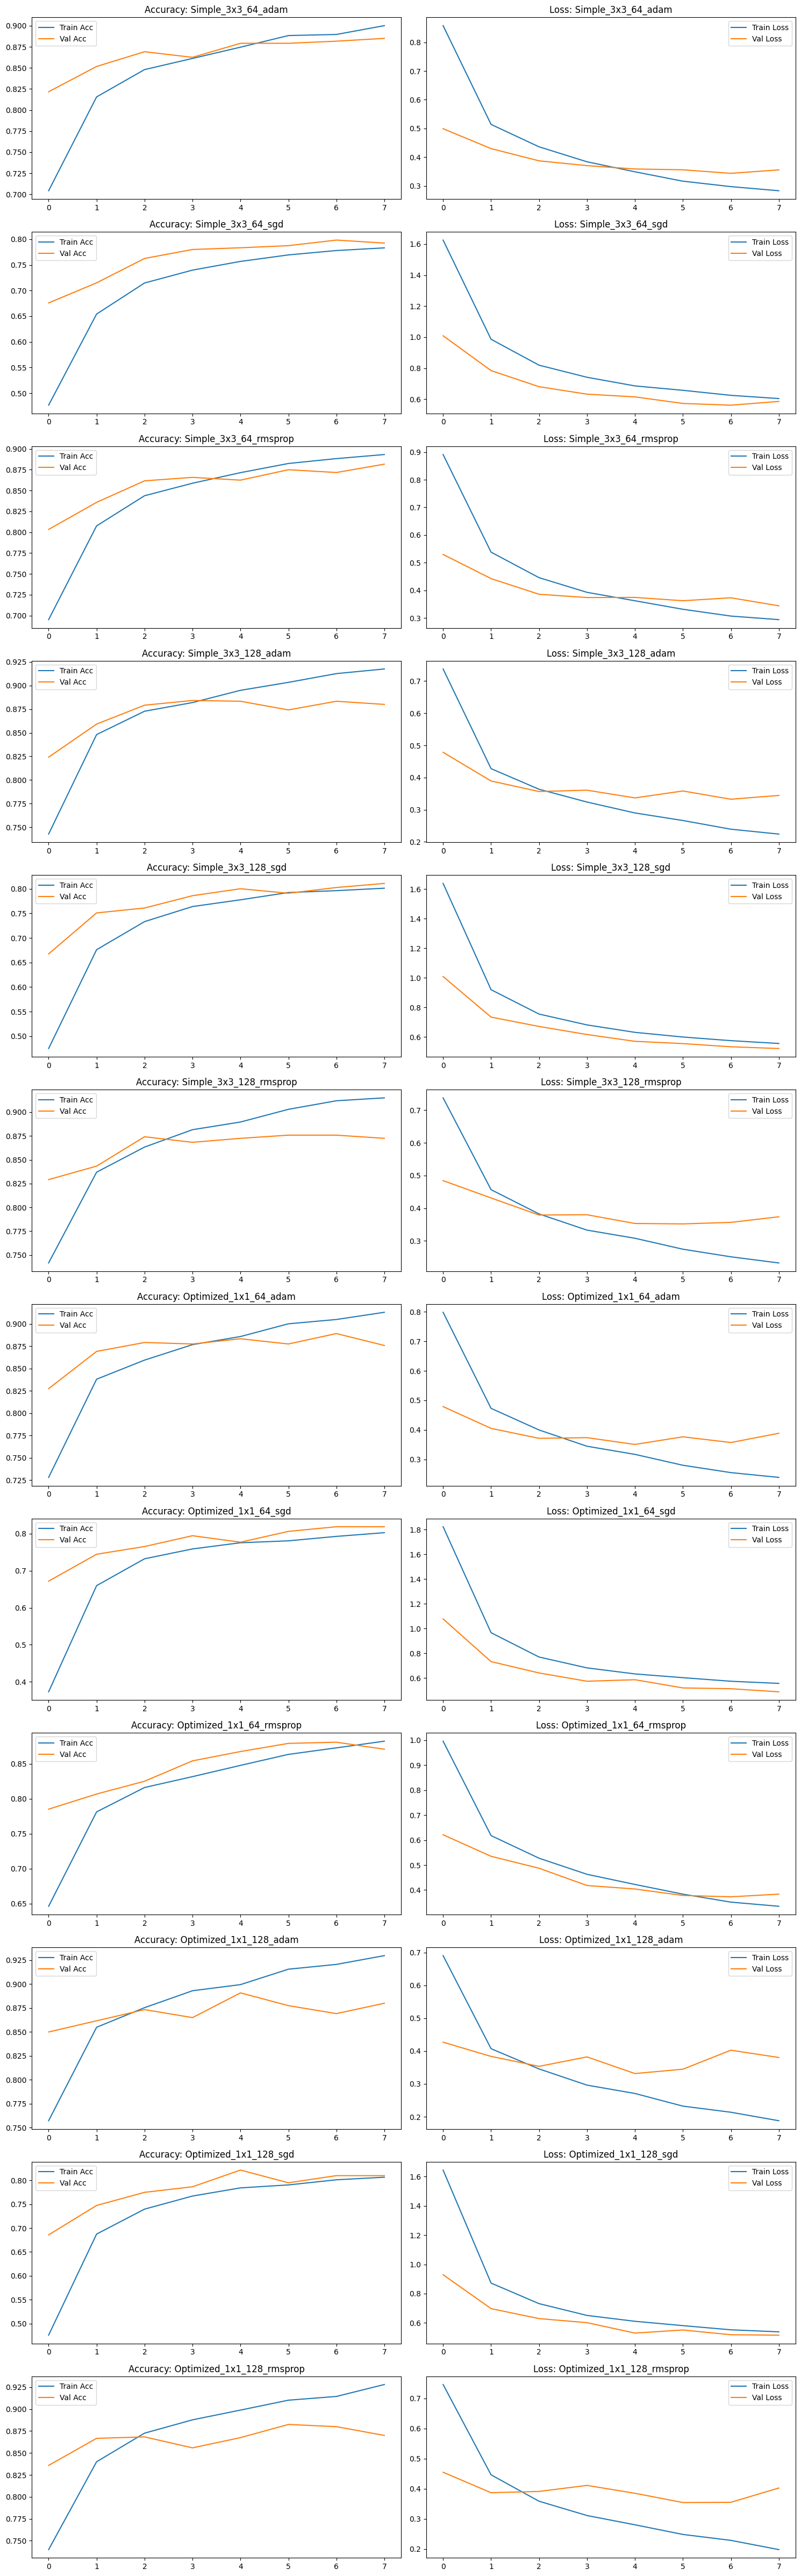


Visualizing last training model predictions:
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step


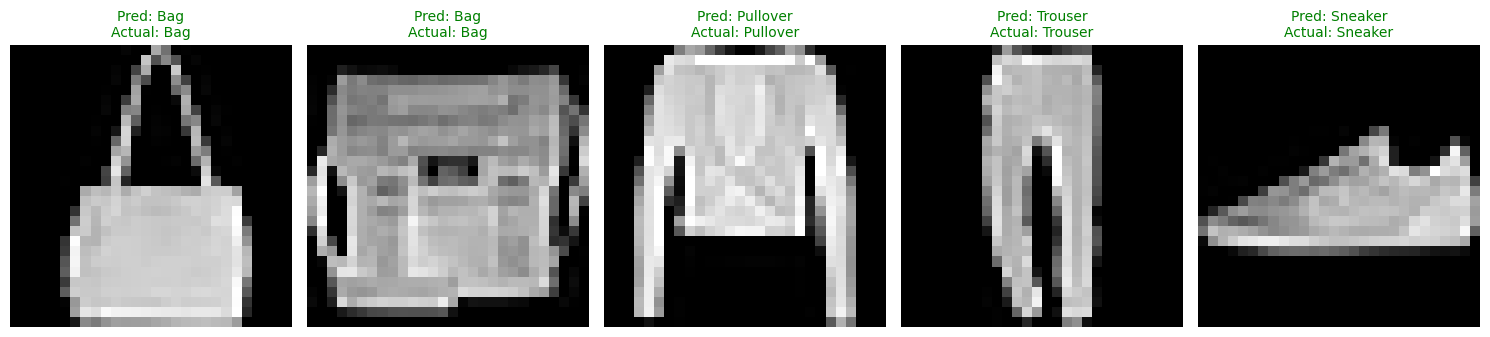


📊 Sample Summary:
✅ Predicted: Ankle boot   | Actual: Ankle boot
✅ Predicted: T-shirt/top  | Actual: T-shirt/top
✅ Predicted: Sneaker      | Actual: Sneaker
❌ Predicted: Shirt        | Actual: Pullover
✅ Predicted: Pullover     | Actual: Pullover


In [ ]:
# After the loop finishes, run the comparison
print("\n" + "="*50)
print("VISUALIZING OVERFITTING TRENDS FOR ALL MODELS")
print("="*50)
plot_all_results(all_histories)

# Also show sample predictions for the very last model
print("\nVisualizing last training model predictions:")
show_sample_predictions(model, X_test, y_test, class_names)


---



---



---



---
---



---



---



---
---



---



---



---
---



---



---



---
---



---



---



---
---



---



---



---
---



---



---



---
---



---



---



---
---



---



---



---



---



---



---



---

# Part 2
# B) GRID SEARCH WITH TENSORBOARD

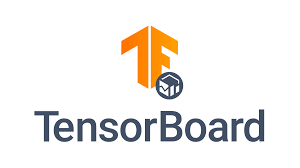

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from tensorboard.plugins.hparams import api as hp
import numpy as np
import time
import os
import shutil

# ============================================
# 1. DATA PREPARATION (CNN VERSION)
# ============================================
def load_and_preprocess_fashion_mnist_cnn(use_subset=True):
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
    X_train_orig, X_test_orig = X_train.copy(), X_test.copy()

    if use_subset:
        n_train = int(X_train.shape[0] * 0.2)
        indices = np.random.choice(X_train.shape[0], n_train, replace=False)
        X_train, y_train = X_train[indices], y_train[indices]

    # Normalization & Reshape for CNN
    X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
    X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0
    print("DATA LOADED, ALL GOOD")

    return X_train, y_train, X_test, y_test, X_train_orig, X_test_orig





In [ ]:

##-----------------------------------------------
# Setup Logging Directory (Cleaning previous runs)
##-----------------------------------------------

log_dir = "logs/final_gridwithtensor"
if os.path.exists(log_dir):
    shutil.rmtree(log_dir) # Clear old logs to keep it clean
os.makedirs(log_dir, exist_ok=True)

##-----------------------------------------------
# 2. Define Hyperparameters (Assg 7 tyle)
##-----------------------------------------------

HP_ARCH = hp.HParam('architecture', hp.Discrete(['Simple_3x3', 'Optimized_1x1']))
HP_NUM_UNITS = hp.HParam('num_units', hp.Discrete([64, 128]))
HP_DROPOUT = hp.HParam('dropout', hp.Discrete([0.3, 0.5]))
HP_OPTIMIZER = hp.HParam('optimizer', hp.Discrete(['adam', 'sgd', 'rmsprop']))
HP_BATCH = hp.HParam('batch_size', hp.Discrete([32, 64]))

#Metric Def
METRIC_ACCURACY = 'accuracy'
METRIC_LOSS_TRAIN = 'loss_train'
METRIC_LOSS_VAL = 'loss_val'


with tf.summary.create_file_writer(log_dir).as_default():
    hp.hparams_config(
        hparams=[HP_ARCH, HP_NUM_UNITS, HP_DROPOUT, HP_OPTIMIZER, HP_BATCH],
        metrics=
         [
            hp.Metric(METRIC_ACCURACY, display_name='Test Accuracy'),
            hp.Metric(METRIC_LOSS_TRAIN, display_name='Train Loss'),
            hp.Metric(METRIC_LOSS_VAL, display_name='Val Loss'),
         ],
       )


In [ ]:
# @title

##-----------------------------------------------
# OLD model Building Function -- it didnt accept log_dirs
##-----------------------------------------------

def train_test_model(hparams):
    model = models.Sequential()
    model.add(tf.keras.Input(shape=(28, 28, 1)))

    # 1x1 vs 3x3 Architecture Trial
    if hparams[HP_ARCH] == 'Optimized_1x1':
        model.add(layers.Conv2D(16, (1, 1), activation='relu'))
        model.add(layers.Conv2D(32, (3, 3), activation='relu'))
    else:
        model.add(layers.Conv2D(32, (3, 3), activation='relu'))

    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(hparams[HP_NUM_UNITS], activation='relu'))
    model.add(layers.Dropout(hparams[HP_DROPOUT]))
    model.add(layers.Dense(10))

    model.compile(
        optimizer=hparams[HP_OPTIMIZER],
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy'],
    )

    # Train the model
    # Note: validation_split=0.1 uses 10% of the SUBSET for validation
    model.fit(
        X_train, y_train,
        epochs=5,
        batch_size=hparams[HP_BATCH],
        validation_split=0.1,
        verbose=0,
        callbacks=[
            tf.keras.callbacks.TensorBoard(log_dir),  # log metrics
            hp.KerasCallback(log_dir, hparams),  # log hparams
        ],
    )

    _, accuracy = model.evaluate(X_test, y_test, verbose=0)
    return accuracy

In [ ]:
# @title


# ============================================
# OLD LOOP --- NO 1x1+3x3 GRID SEARCH LOOP (WITH SUB-DIRECTORIES)
# ============================================
session_num = 0

for arch in HP_ARCH.domain.values:
    for num_units in HP_NUM_UNITS.domain.values:
        for dropout_rate in HP_DROPOUT.domain.values:
            for optimizer in HP_OPTIMIZER.domain.values:
                for batch in HP_BATCH.domain.values:
                    hparams = {
                        HP_ARCH: arch,
                        HP_NUM_UNITS: num_units,
                        HP_DROPOUT: dropout_rate,
                        HP_OPTIMIZER: optimizer,
                        HP_BATCH: batch
                    }

                    # CREATE UNIQUE SUB-DIRECTORY FOR EACH RUN
                    run_name = f"run-{session_num}"
                    run_log_dir = os.path.join(log_dir, run_name)

                    print(f"--- Starting trial: {run_name}")
                    print({h.name: hparams[h] for h in hparams})

                    # 1. Build and compile the model
                    model = models.Sequential([
                        tf.keras.Input(shape=(28, 28, 1)),
                        layers.Conv2D(16, (1, 1) if hparams[HP_ARCH] == 'Optimized_1x1' else (3, 3), activation='relu'),
                        layers.Conv2D(32, (3, 3), activation='relu'),
                        layers.MaxPooling2D((2, 2)),
                        layers.Flatten(),
                        layers.Dense(hparams[HP_NUM_UNITS], activation='relu'),
                        layers.Dropout(hparams[HP_DROPOUT]),
                        layers.Dense(10)
                    ])

                    model.compile(
                        optimizer=hparams[HP_OPTIMIZER],
                        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                        metrics=['accuracy'],
                    )

                    # 2. Train with the correct run-specific log directory
                    model.fit(
                        X_train, y_train,
                        epochs=5,
                        batch_size=hparams[HP_BATCH],
                        validation_split=0.1,
                        verbose=0,
                        callbacks=[
                            tf.keras.callbacks.TensorBoard(run_log_dir),
                            hp.KerasCallback(run_log_dir, hparams), # Logs hparams to sub-dir
                        ],
                    )

                    # 3. Evaluate and log the final metric explicitly for HParams
                    _, accuracy = model.evaluate(X_test, y_test, verbose=0)

                    with tf.summary.create_file_writer(run_log_dir).as_default():
                        hp.hparams(hparams) # record the values used in this trial
                        tf.summary.scalar(METRIC_ACCURACY, accuracy, step=1)

                    print(f"Accuracy: {accuracy:.4f}")
                    session_num += 1

In [ ]:
#=======================================
### UPDATED MODEL FUNCTION - H PARAMS IMPLEMENTATION
#====================================
def train_test_model(hparams, run_log_dir): # Now accepts the directory!
    model = models.Sequential()
    model.add(tf.keras.Input(shape=(28, 28, 1)))

    # Architecture Logic
    if hparams[HP_ARCH] == 'Optimized_1x1':
        # Chain: 1x1 THEN 3x3
        model.add(layers.Conv2D(16, (1, 1), activation='relu'))
        model.add(layers.Conv2D(32, (3, 3), activation='relu'))
    else:
        # Just 3x3
        model.add(layers.Conv2D(32, (3, 3), activation='relu'))

    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(hparams[HP_NUM_UNITS], activation='relu'))
    model.add(layers.Dropout(hparams[HP_DROPOUT]))
    model.add(layers.Dense(10))

    model.compile(
        optimizer=hparams[HP_OPTIMIZER],
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy'],
    )

    # Capture history to get losses
    history = model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=hparams[HP_BATCH],
        validation_split=0.1, ##--> validation_data=(X_test, y_test), # Using X_test for validation during search
        verbose=0,
        callbacks=[
            tf.keras.callbacks.TensorBoard(run_log_dir),
            hp.KerasCallback(run_log_dir, hparams),
        ],
    )

    # Evaluate on test set for accuracy
    _, accuracy = model.evaluate(X_test, y_test, verbose=0)

    # Get losses from the very last epoch
    train_loss = history.history['loss'][-1]
    val_loss = history.history['val_loss'][-1]


    # LOG ALL THREE METRICS
    with tf.summary.create_file_writer(run_log_dir).as_default():
        hp.hparams(hparams)
        tf.summary.scalar(METRIC_ACCURACY, accuracy, step=1)
        tf.summary.scalar(METRIC_LOSS_TRAIN, train_loss, step=1)
        tf.summary.scalar(METRIC_LOSS_VAL, val_loss, step=1)

    # NOW RETURNING 4 VALUES: accuracy, train_loss, val_loss, AND history
    return accuracy, train_loss, val_loss, history

In [ ]:
##-----------------------
## LOAD DATA
##-----------------------

X_train, y_train, X_test, y_test, X_orig, X_test_orig = load_and_preprocess_fashion_mnist_cnn() #We can erase "use_subset=True" to use full dataset
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


# Create a list to store results for ranking
all_results = []


#==================================
# Updated grid search loop using model function
#==================================

session_num = 0

for arch in HP_ARCH.domain.values:
    for num_units in HP_NUM_UNITS.domain.values:
        for dropout_rate in HP_DROPOUT.domain.values:
            for optimizer in HP_OPTIMIZER.domain.values:
                for batch in HP_BATCH.domain.values:
                    hparams = {
                        HP_ARCH: arch,
                        HP_NUM_UNITS: num_units,
                        HP_DROPOUT: dropout_rate,
                        HP_OPTIMIZER: optimizer,
                        HP_BATCH: batch
                    }


                    ##
                    # CREATE UNIQUE SUB-DIRECTORY FOR EACH RUN
                    run_name = f"run-{session_num}"

                    # Define the path here and pass it to your function
                    run_log_dir = os.path.join(log_dir, run_name)

                    print(f"--- Starting trial: {run_name}")
                    print({h.name: hparams[h] for h in hparams})



                    ## MODIFY train_test_model to return the 'history' object as well
                    # For now, let's assume we capture the 4 values:
                    acc, t_loss, v_loss, history = train_test_model(hparams, run_log_dir)




                    print(f"Accuracy: {acc:.4f} | Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f}")

                    #Re-instantiate the model structure to "save" the trained state
                    # We store the 'model' object itself in the dictionary

                    all_results.append({
                        'hparams': hparams,
                        'accuracy': acc,
                        'history': history,
                        'model': tf.keras.models.clone_model(model), # Save architecture
                        'weights': model.get_weights(),              # Save trained weights
                        'run_name': run_name
                    })

                    session_num += 1



DATA LOADED, ALL GOOD
--- Starting trial: run-0
{'architecture': 'Optimized_1x1', 'num_units': 64, 'dropout': 0.3, 'optimizer': 'adam', 'batch_size': 32}
Accuracy: 0.8843 | Train Loss: 0.1914 | Val Loss: 0.3374
--- Starting trial: run-1
{'architecture': 'Optimized_1x1', 'num_units': 64, 'dropout': 0.3, 'optimizer': 'adam', 'batch_size': 64}
Accuracy: 0.8808 | Train Loss: 0.2157 | Val Loss: 0.3393
--- Starting trial: run-2
{'architecture': 'Optimized_1x1', 'num_units': 64, 'dropout': 0.3, 'optimizer': 'rmsprop', 'batch_size': 32}
Accuracy: 0.8845 | Train Loss: 0.2107 | Val Loss: 0.3577
--- Starting trial: run-3
{'architecture': 'Optimized_1x1', 'num_units': 64, 'dropout': 0.3, 'optimizer': 'rmsprop', 'batch_size': 64}
Accuracy: 0.8824 | Train Loss: 0.2514 | Val Loss: 0.3240
--- Starting trial: run-4
{'architecture': 'Optimized_1x1', 'num_units': 64, 'dropout': 0.3, 'optimizer': 'sgd', 'batch_size': 32}
Accuracy: 0.7955 | Train Loss: 0.4682 | Val Loss: 0.5568
--- Starting trial: run-5
{'

###
# Plot top 3 models
###

In [ ]:

# 3. Sort by accuracy and get the top 3
top_3_data = sorted(all_results, key=lambda x: x['accuracy'], reverse=True)[:3]

# 4. Re-load the weights into the top 3 models
# (This step is necessary because clone_model doesn't copy weights automatically)
for item in top_3_data:
    item['model'].set_weights(item['weights'])

In [ ]:
def visualize_model_predictions(model, title, num_images=5):
    # Get predictions for the first few images of X_test
    predictions_raw = model.predict(X_test[:num_images], verbose=0)
    predictions = np.argmax(predictions_raw, axis=1)

    plt.figure(figsize=(15, 3))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        plt.imshow(X_test[i].reshape(28, 28), cmap='gray')

        pred_label = class_names[predictions[i]]
        true_label = class_names[y_test[i]]

        color = 'green' if predictions[i] == y_test[i] else 'red'
        plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color, fontsize=9)
        plt.axis('off')
    plt.suptitle(f"Sample Predictions: {title}", fontsize=14)
    plt.show()

    # --- DISPLAY EVERYTHING ---
for i, model_data in enumerate(top_3_data):
    print(f"\nRANK {i+1} MODEL")

    # Show the Training/Validation Curves (Overfitting check)
    plot_top_models([model_data]) # Uses your existing plotting function

    # Show the actual Image Predictions
    visualize_model_predictions(model_data['model'], f"Rank {i+1} Predictions")

##Visualize with tensorboard

In [ ]:
!kill $(pgrep tensorboard) ## this is to clean previous data
%load_ext tensorboard
%tensorboard --logdir "logs/final_gridwithtensor"

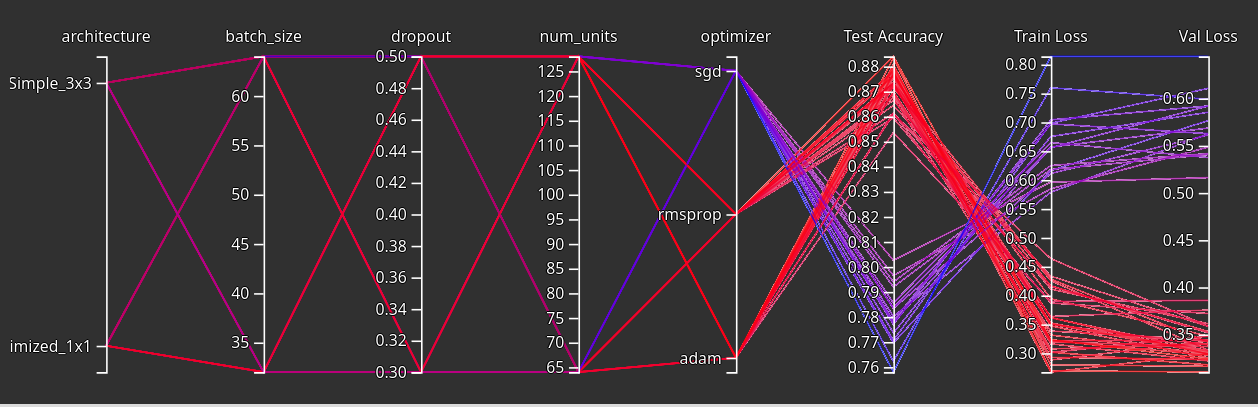

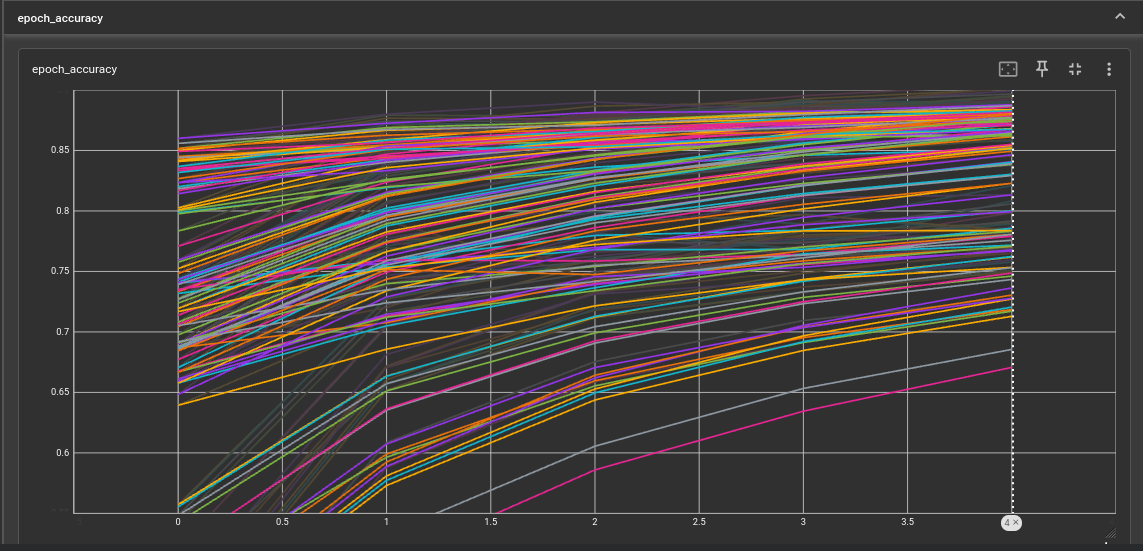